In [40]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/diets.csv
/kaggle/input/medications.csv
/kaggle/input/Symptom-severity.csv
/kaggle/input/workout_df.csv
/kaggle/input/precautions_df.csv
/kaggle/input/Training.csv
/kaggle/input/description.csv
/kaggle/input/symtoms_df.csv


In [41]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

******Checking the report of Data******

Using the ydataprofilling Technique it gives the report of data in HTML format to check whether the data having missing values, Imbalacing of data or some corellation of data...


In [42]:

# Load datasets
dataset = pd.read_csv('/kaggle/input/Training.csv')
sym_des = pd.read_csv('/kaggle/input/symtoms_df.csv')
precautions = pd.read_csv('/kaggle/input/precautions_df.csv')
workout = pd.read_csv('/kaggle/input/workout_df.csv')
description = pd.read_csv('/kaggle/input/description.csv')
medications = pd.read_csv('/kaggle/input/medications.csv')
diets = pd.read_csv('/kaggle/input/diets.csv')

This code Snippet gives the report

Labeling of Target and Splitting of data

In [45]:
def preprocess_data(dataset):
    # Separate features and target
    X = dataset.drop(labels=['prognosis'], axis=1)
    y = dataset['prognosis']
    
    # Encode labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    
    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=0)
    
    return X_train, X_test, y_train, y_test, le

X_train, X_test, y_train, y_test, label_encoder = preprocess_data(dataset)

In [46]:
# Feature Selection
def select_features(X_train, X_test, y_train, k=30):
    selector = SelectKBest(mutual_info_classif, k=k)
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)
    selected_features = X_train.columns[selector.get_support()]
    return X_train_selected, X_test_selected, selected_features

X_train_selected, X_test_selected, selected_features = select_features(X_train, X_test, y_train)

print(f"Top {len(selected_features)} Selected Features:")
print(selected_features.tolist())

Top 30 Selected Features:
['itching', 'skin_rash', 'chills', 'joint_pain', 'vomiting', 'fatigue', 'weight_loss', 'lethargy', 'cough', 'high_fever', 'breathlessness', 'sweating', 'headache', 'yellowish_skin', 'dark_urine', 'nausea', 'loss_of_appetite', 'abdominal_pain', 'diarrhoea', 'mild_fever', 'yellowing_of_eyes', 'swelled_lymph_nodes', 'malaise', 'blurred_and_distorted_vision', 'phlegm', 'chest_pain', 'excessive_hunger', 'loss_of_balance', 'irritability', 'muscle_pain']


**Plotting the data which have highly correlated features**

In [47]:
# Neural Network Model
def build_model(input_dim, num_classes):
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = build_model(input_dim=X_train_selected.shape[1], num_classes=len(np.unique(y_train)))
model.summary()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 41)             │         1,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,417 (21.16 KB)

 Trainable params: 5,417 (21.16 KB)

 Non-trainable params: 0 (0.00 B)

**Using Feature Selection Technique**

In [48]:
# Train the Model
history = model.fit(
    X_train_selected, y_train,
    validation_data=(X_test_selected, y_test),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.0597 - loss: 3.6294 - val_accuracy: 0.4634 - val_loss: 3.0322
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3032 - loss: 2.8326 - val_accuracy: 0.7812 - val_loss: 1.7730
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5371 - loss: 1.8554 - val_accuracy: 0.8760 - val_loss: 0.9485
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6782 - loss: 1.2491 - val_accuracy: 0.8970 - val_loss: 0.5754
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7540 - loss: 0.9409 - val_accuracy: 0.9065 - val_loss: 0.4028
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7766 - loss: 0.7709 - val_accuracy: 0.8984 - val_loss: 0.3244
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7842 - loss: 0.6782 - val_accuracy: 0.9004 - val_loss: 0.2882
Epoch 8/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8156 - loss: 0.6051 - val_accu

In [49]:
# Evaluate the Model
train_pred = np.argmax(model.predict(X_train_selected), axis=1)
test_pred = np.argmax(model.predict(X_test_selected), axis=1)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print(f"Train Accuracy: {train_accuracy * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Train Accuracy: 90.33%
Test Accuracy: 91.26%


In [50]:
# Overfitting Check
if train_accuracy - test_accuracy > 0.1:
    print("The model is likely overfitting.")
else:
    print("The model generalizes well.")

The model generalizes well.


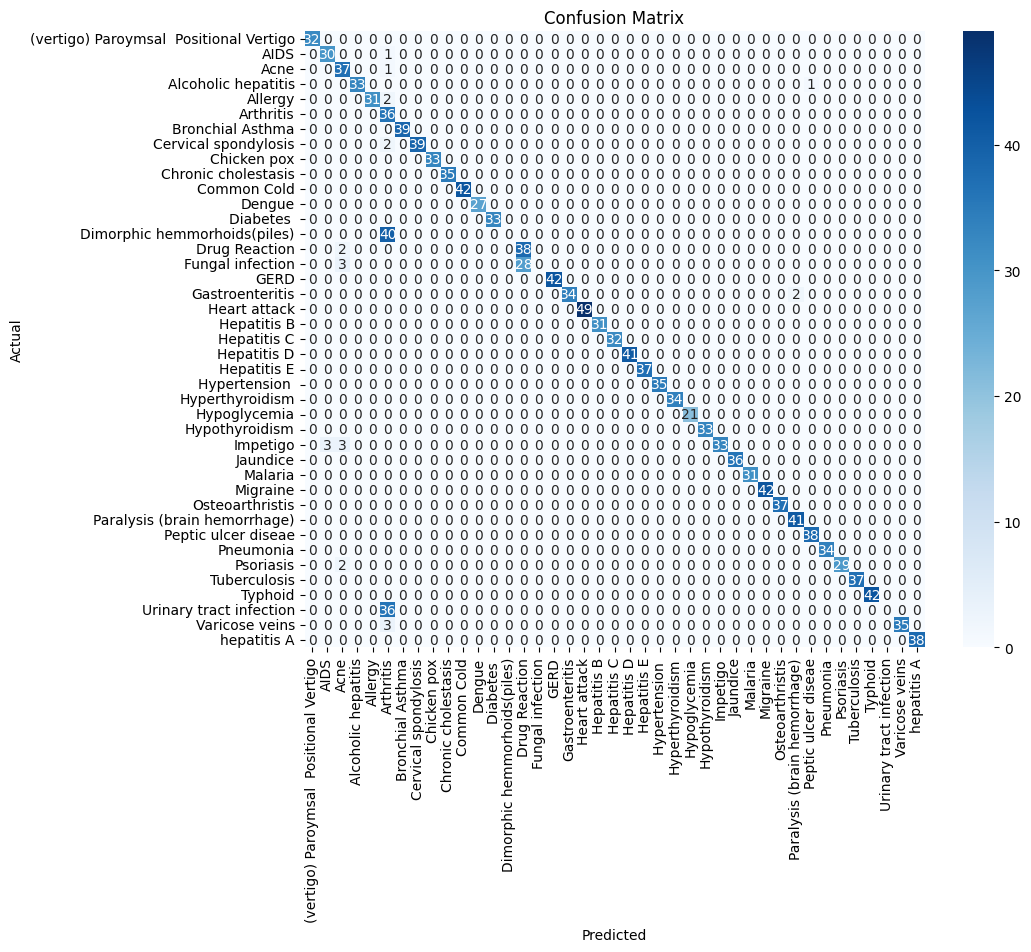

In [51]:
# Confusion Matrix
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [52]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test, test_pred, target_names=label_encoder.classes_))

Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        32
                                   AIDS       0.91      0.97      0.94        31
                                   Acne       0.79      0.97      0.87        38
                    Alcoholic hepatitis       1.00      0.97      0.99        34
                                Allergy       1.00      0.94      0.97        33
                              Arthritis       0.30      1.00      0.46        36
                       Bronchial Asthma       1.00      1.00      1.00        39
                   Cervical spondylosis       1.00      0.95      0.97        41
                            Chicken pox       1.00      1.00      1.00        33
                    Chronic cholestasis       1.00      1.00      1.00        35
                            Common Cold       1.00      1.00      1.00        42
    

/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [53]:
# Save and Load Model
model.save('nn_model.h5')
loaded_model = tf.keras.models.load_model('nn_model.h5')


In [55]:
# Example Prediction
# Ensure the selected features are used to filter X_test columns
example_input = X_test.iloc[0][selected_features].values.reshape(1, -1)  # Select only the relevant features
example_pred = np.argmax(loaded_model.predict(example_input), axis=1)  # Predict the class
predicted_disease = label_encoder.inverse_transform(example_pred)[0]  # Decode the predicted class
actual_disease = label_encoder.inverse_transform([y_test[0]])[0]  # Decode the actual class

print("Actual Disease:", actual_disease)
print("Predicted Disease:", predicted_disease)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Actual Disease: Heart attack
Predicted Disease: Heart attack


In [ ]:
from ydata_profiling import ProfileReport
profile = ProfileReport(X_train_selected , title="Profiling Report")
profile.to_file("Selected_profiling_report.html")

In [39]:
import numpy as np

# Ensure that the test set has the same features as the training set
X_test_selected = X_test.loc[:, sel_five_cols.get_support()]

# Convert the selected features to a float numpy array (same as for training data)
X_test_selected = to_float_numpy(X_test_selected)

# Get the predictions for the test set (probabilities)
nn_pred = model.predict(X_test_selected)

# For multi-class classification, you can use np.argmax to get the class with the highest probability
nn_pred_class = np.argmax(nn_pred, axis=1)

# Reset the index of y_test to align with the predictions
y_test = y_test.reset_index(drop=True)

# Assuming these are your class labels in the same order as the model was trained
class_labels = ["Disease1", "Disease2", "Heart attack", "Disease4", "Disease5", "Disease6", ...]  # Replace with your actual class labels

# Debugging print to check the predicted class
print("Predicted Class Index:", nn_pred_class[0])
print("Number of Class Labels:", len(class_labels))

# Check if the predicted class index is within the bounds of class_labels
if nn_pred_class[0] < len(class_labels):
    predicted_disease = class_labels[nn_pred_class[0]]
else:
    print(f"Error: Predicted class index {nn_pred_class[0]} is out of range for class_labels.")
    predicted_disease = "Unknown"

# Print actual and predicted values for the first instance
print("Actual Disease:", y_test[0])
print("Predicted Disease:", predicted_disease)


47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predicted Class Index: 18
Number of Class Labels: 7
Error: Predicted class index 18 is out of range for class_labels.
Actual Disease: Heart attack
Predicted Disease: Unknown


In [65]:
import numpy as np
from fuzzywuzzy import process  # Install via: pip install fuzzywuzzy python-Levenshtein

# Define symptoms dictionary
symptoms_dict = {
    'itching': 0, 'skin_rash': 1, 'nodal_skin_eruptions': 2, 'continuous_sneezing': 3, 'shivering': 4,
    'chills': 5, 'joint_pain': 6, 'stomach_pain': 7, 'acidity': 8, 'ulcers_on_tongue': 9, 'muscle_wasting': 10,
    'vomiting': 11, 'burning_micturition': 12, 'spotting_ urination': 13, 'fatigue': 14, 'weight_gain': 15,
    'anxiety': 16, 'cold_hands_and_feets': 17, 'mood_swings': 18, 'weight_loss': 19, 'restlessness': 20,
    'lethargy': 21, 'patches_in_throat': 22, 'irregular_sugar_level': 23, 'cough': 24, 'high_fever': 25,
    'sunken_eyes': 26, 'breathlessness': 27, 'sweating': 28, 'dehydration': 29, 'indigestion': 30, 'headache': 31,
    'yellowish_skin': 32, 'dark_urine': 33, 'nausea': 34, 'loss_of_appetite': 35, 'pain_behind_the_eyes': 36,
    'back_pain': 37, 'constipation': 38, 'abdominal_pain': 39, 'diarrhoea': 40, 'mild_fever': 41, 'yellow_urine': 42,
    'yellowing_of_eyes': 43, 'acute_liver_failure': 44, 'fluid_overload': 45, 'swelling_of_stomach': 46,
    'swelled_lymph_nodes': 47, 'malaise': 48, 'blurred_and_distorted_vision': 49, 'phlegm': 50, 'throat_irritation': 51,
    'redness_of_eyes': 52, 'sinus_pressure': 53, 'runny_nose': 54, 'congestion': 55, 'chest_pain': 56,
    'weakness_in_limbs': 57, 'fast_heart_rate': 58, 'pain_during_bowel_movements': 59, 'pain_in_anal_region': 60,
    'bloody_stool': 61, 'irritation_in_anus': 62, 'neck_pain': 63, 'dizziness': 64, 'cramps': 65, 'bruising': 66,
    'obesity': 67, 'swollen_legs': 68, 'swollen_blood_vessels': 69, 'puffy_face_and_eyes': 70, 'enlarged_thyroid': 71,
    'brittle_nails': 72, 'swollen_extremeties': 73, 'excessive_hunger': 74, 'extra_marital_contacts': 75,
    'drying_and_tingling_lips': 76, 'slurred_speech': 77, 'knee_pain': 78, 'hip_joint_pain': 79, 'muscle_weakness': 80,
    'stiff_neck': 81, 'swelling_joints': 82, 'movement_stiffness': 83, 'spinning_movements': 84, 'loss_of_balance': 85,
    'unsteadiness': 86, 'weakness_of_one_body_side': 87, 'loss_of_smell': 88, 'bladder_discomfort': 89,
    'foul_smell_of urine': 90, 'continuous_feel_of_urine': 91, 'passage_of_gases': 92, 'internal_itching': 93,
    'toxic_look_(typhos)': 94, 'depression': 95, 'irritability': 96, 'muscle_pain': 97, 'altered_sensorium': 98,
    'red_spots_over_body': 99, 'belly_pain': 100, 'abnormal_menstruation': 101, 'dischromic _patches': 102,
    'watering_from_eyes': 103, 'increased_appetite': 104, 'polyuria': 105, 'family_history': 106, 'mucoid_sputum': 107,
    'rusty_sputum': 108, 'lack_of_concentration': 109, 'visual_disturbances': 110, 'receiving_blood_transfusion': 111,
    'receiving_unsterile_injections': 112, 'coma': 113, 'stomach_bleeding': 114, 'distention_of_abdomen': 115,
    'history_of_alcohol_consumption': 116, 'fluid_overload.1': 117, 'blood_in_sputum': 118, 'prominent_veins_on_calf': 119,
    'palpitations': 120, 'painful_walking': 121, 'pus_filled_pimples': 122, 'blackheads': 123, 'scurring': 124,
    'skin_peeling': 125, 'silver_like_dusting': 126, 'small_dents_in_nails': 127, 'inflammatory_nails': 128,
    'blister': 129, 'red_sore_around_nose': 130, 'yellow_crust_ooze': 131
}

# Helper function to fetch disease-related information
def helper(dis):
    # Fetch description
    desc = description[description['Disease'] == dis]['Description']
    desc = " ".join([w for w in desc]) if not desc.empty else "No description available."

    # Fetch precautions
    pre = precautions[precautions['Disease'] == dis][['Precaution_1', 'Precaution_2', 'Precaution_3', 'Precaution_4']]
    pre = [col for col in pre.values.flatten() if isinstance(col, str)] if not pre.empty else ["No precautions available."]

    # Fetch medications
    med = medications[medications['Disease'] == dis]['Medication']
    med = [m for m in med.values] if not med.empty else ["No medications available."]

    # Fetch diet recommendations
    die = diets[diets['Disease'] == dis]['Diet']
    die = [d for d in die.values] if not die.empty else ["No diet recommendations available."]

    # Fetch workout recommendations
    wrkout = workout[workout['disease'] == dis]['workout']
    wrkout = [w for w in wrkout.values] if not wrkout.empty else ["No workout recommendations available."]

    return desc, pre, med, die, wrkout

# Function to predict top three diseases based on patient symptoms using softmax probabilities
def get_top_three_predictions(patient_symptoms):
    # Normalize symptoms (convert to lowercase)
    patient_symptoms = [symptom.lower().strip() for symptom in patient_symptoms]
    
    # Match symptoms using fuzzy matching
    matched_symptoms = []
    unmatched_symptoms = []
    all_symptoms = list(symptoms_dict.keys())
    
    for symptom in patient_symptoms:
        # Find the best match using fuzzy matching
        match, score = process.extractOne(symptom, all_symptoms)
        if score >= 70:  # Accept matches with a similarity score of 70% or higher
            matched_symptoms.append(match)
        else:
            unmatched_symptoms.append(symptom)
    
    # Warn about unmatched symptoms
    if unmatched_symptoms:
        print(f"Warning: The following symptoms were not recognized: {', '.join(unmatched_symptoms)}")
    
    # Create input vector aligned with all features
    input_vector = np.zeros(len(symptoms_dict))
    for symptom in matched_symptoms:
        if symptom in symptoms_dict:  # Ensure the symptom exists in the dictionary
            input_vector[symptoms_dict[symptom]] = 1

    # Convert selected_features to integer indices
    selected_feature_indices = [symptoms_dict[feature] for feature in selected_features if feature in symptoms_dict]

    # Filter input vector to include only selected features
    input_vector_selected = input_vector[selected_feature_indices].reshape(1, -1)

    # Predict softmax probabilities for all diseases
    probabilities = loaded_model.predict(input_vector_selected)[0]
    
    # Rank diseases by softmax probabilities
    top_indices = np.argsort(probabilities)[::-1][:3]  # Get indices of top 3 probabilities
    top_diseases = label_encoder.inverse_transform(top_indices)  # Decode disease names
    top_probabilities = probabilities[top_indices]  # Get corresponding probabilities

    # Prepare results for top three diseases
    results = []
    for i, (disease, prob) in enumerate(zip(top_diseases, top_probabilities)):
        desc, pre, med, die, wrkout = helper(disease)
        results.append({
            "Rank": i + 1,
            "Disease": disease,
            "Probability": f"{prob * 100:.2f}%",
            "Description": desc,
            "Precautions": pre,
            "Medications": med,
            "Diet Recommendations": die,
            "Workout Recommendations": wrkout
        })

    return results

# User input
symptoms_input = input("Enter your symptoms (comma-separated): ")
user_symptoms = [s.strip() for s in symptoms_input.split(',')]

# Predict the top three diseases and fetch details
results = get_top_three_predictions(user_symptoms)

# Display Results
print("\n================= Top Three Predicted Diseases ==============")
for result in results:
    print(f"\nRank: {result['Rank']}")
    print(f"Disease: {result['Disease']} (Probability: {result['Probability']})")
    print("Description:")
    print(result["Description"])
    print("\nPrecautions:")
    for i, p in enumerate(result["Precautions"], start=1):
        print(f"{i}: {p}")
    print("\nMedications:")
    for i, m in enumerate(result["Medications"], start=1):
        print(f"{i}: {m}")
    print("\nDiet Recommendations:")
    for i, d in enumerate(result["Diet Recommendations"], start=1):
        print(f"{i}: {d}")
    print("\nWorkout Recommendations:")
    for i, w in enumerate(result["Workout Recommendations"], start=1):
        print(f"{i}: {w}")

Enter your symptoms (comma-separated):  Abdominal_pain,bleeding,hard_stool,loss_of_appetite


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step

================= Top Three Predicted Diseases ==============

Rank: 1
Disease: Peptic ulcer diseae (Probability: 99.97%)
Description:
No description available.

Precautions:
1: avoid fatty spicy food
2: consume probiotic food
3: eliminate milk
4: limit alcohol

Medications:
1: No medications available.

Diet Recommendations:
1: No diet recommendations available.

Workout Recommendations:
1: No workout recommendations available.

Rank: 2
Disease: Alcoholic hepatitis (Probability: 0.02%)
Description:
Alcoholic hepatitis is inflammation of the liver due to alcohol consumption.

Precautions:
1: stop alcohol consumption
2: consult doctor
3: medication
4: follow up

Medications:
1: ['Antibiotics', 'Isoniazid', 'Rifampin', 'Ethambutol', 'Pyrazinamide']

Diet Recommendations:
1: ['Liver-Healthy Diet', 'Low-fat Diet', 'Fruits and vegetables', 'Whole grains', 'Lean proteins']

Workout Recommendations:
1: Avoid alcohol consumption
2: Follow a balanced and n